# CIFAR-10 CNN: Conv-BN-ReLU Blocks, Optimizers, Residuals, and Ablations

This notebook implements a Convolutional Neural Network for CIFAR-10 classification with:
1. **Conv-BN-ReLU blocks** - Building blocks of modern CNNs
2. **Data augmentations** - Improve generalization
3. **Optimizer comparison** - SGD vs AdamW
4. **Residual connections** - Enable deeper networks
5. **Ablation studies** - Understand component contributions

## Goals
- Implement Conv-BN-ReLU blocks from scratch
- Train on CIFAR-10 dataset
- Compare SGD vs AdamW optimizers
- Add residual connections
- Perform ablation studies (remove components to see their effect)


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from collections import defaultdict

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")


Using device: cpu


## 1. Conv-BN-ReLU Block Implementation

A Conv-BN-ReLU block consists of:
1. **Convolutional layer** - Learns spatial features
2. **Batch Normalization** - Normalizes activations, stabilizes training
3. **ReLU activation** - Introduces non-linearity

This is the fundamental building block of modern CNNs.


In [3]:
class ConvBNReLU(nn.Module):
    """
    Conv-BN-ReLU block: Convolution -> BatchNorm -> ReLU
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class ResidualBlock(nn.Module):
    """
    Residual block with skip connection: Conv-BN-ReLU -> Conv-BN -> Add -> ReLU
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # Skip connection: if dimensions change, use 1x1 conv
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity  # Residual connection
        out = self.relu(out)
        return out


## 2. CNN Architecture

We'll build a CNN with Conv-BN-ReLU blocks. We'll create versions with and without residual connections.


In [4]:
class SimpleCNN(nn.Module):
    """
    Simple CNN using Conv-BN-ReLU blocks (no residuals)
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Initial conv layer
        self.conv1 = ConvBNReLU(3, 64, kernel_size=3, padding=1)
        
        # Conv blocks
        self.conv2 = ConvBNReLU(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        
        self.conv3 = ConvBNReLU(64, 128, kernel_size=3, padding=1)
        self.conv4 = ConvBNReLU(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        
        self.conv5 = ConvBNReLU(128, 256, kernel_size=3, padding=1)
        self.conv6 = ConvBNReLU(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 8x8 -> 4x4
        
        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class ResNetCNN(nn.Module):
    """
    CNN with residual connections
    """
    def __init__(self, num_classes=10):
        super(ResNetCNN, self).__init__()
        # Initial conv layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual blocks
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        
        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def count_parameters(model):
    """Count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Test models
simple_model = SimpleCNN().to(device)
resnet_model = ResNetCNN().to(device)

print(f"SimpleCNN parameters: {count_parameters(simple_model):,}")
print(f"ResNetCNN parameters: {count_parameters(resnet_model):,}")


SimpleCNN parameters: 1,148,874
ResNetCNN parameters: 2,777,674


## 3. Load CIFAR-10 Dataset

CIFAR-10 has 10 classes, 32x32 RGB images, 50k training + 10k test images.


In [5]:
# CIFAR-10 class names
CIFAR10_CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Data transforms
# For training: normalization + augmentations
# For testing: only normalization
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load datasets
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Create data loaders
batch_size = 128
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
print(f"Batch size: {batch_size}")
print(f"Number of batches per epoch: {len(trainloader)}")


100%|██████████| 170M/170M [00:19<00:00, 8.84MB/s] 


Training samples: 50000
Test samples: 10000
Batch size: 128
Number of batches per epoch: 391


## 4. Visualize CIFAR-10 Data

Let's look at some sample images from the dataset.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7402936].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.57883847..1.059187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.65637815..1.5549458].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.0476782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6

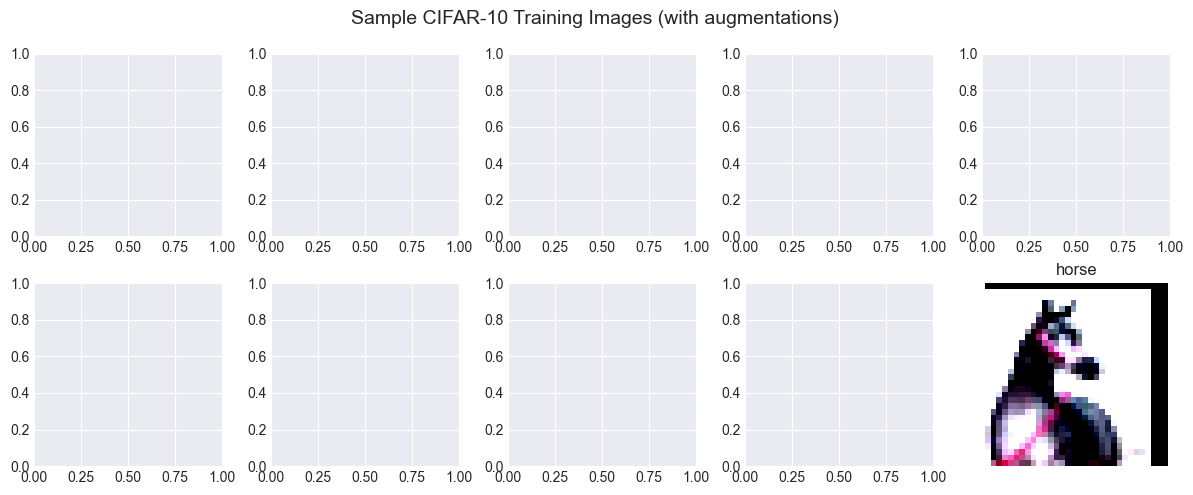

In [6]:
def imshow(img, title=""):
    """Denormalize and display image"""
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    imshow(images[i], CIFAR10_CLASSES[labels[i]])
plt.suptitle('Sample CIFAR-10 Training Images (with augmentations)', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Training Functions

We'll create training and evaluation functions that work with different optimizers.


In [7]:
def train_epoch(model, trainloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(trainloader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, testloader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(testloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_model(model, trainloader, testloader, optimizer, num_epochs=10, 
                lr_scheduler=None, device='cuda', model_name='model'):
    """Complete training loop"""
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    best_test_acc = 0.0
    
    print(f"\nTraining {model_name}...")
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)
        
        # Evaluate
        test_loss, test_acc = evaluate(model, testloader, criterion, device)
        
        # Update learning rate
        if lr_scheduler:
            lr_scheduler.step()
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        # Print progress
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
        
        # Save best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
    
    print(f"\nBest test accuracy: {best_test_acc:.2f}%")
    return history


In [8]:
num_epochs = 20
learning_rate = 0.001

# Model 1: SimpleCNN with SGD
print("=" * 60)
model_sgd = SimpleCNN().to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler_sgd = optim.lr_scheduler.CosineAnnealingLR(optimizer_sgd, T_max=num_epochs)

history_sgd = train_model(
    model_sgd, trainloader, testloader, optimizer_sgd, 
    num_epochs=num_epochs, lr_scheduler=scheduler_sgd, 
    device=device, model_name='SimpleCNN + SGD'
)

# Model 2: SimpleCNN with AdamW
print("\n" + "=" * 60)
model_adamw = SimpleCNN().to(device)
optimizer_adamw = optim.AdamW(model_adamw.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=num_epochs)

history_adamw = train_model(
    model_adamw, trainloader, testloader, optimizer_adamw,
    num_epochs=num_epochs, lr_scheduler=scheduler_adamw,
    device=device, model_name='SimpleCNN + AdamW'
)



Training SimpleCNN + SGD...


Epoch 1/20: Train Loss: 1.6583, Train Acc: 39.70% | Test Loss: 1.3676, Test Acc: 49.59%


Epoch 2/20: Train Loss: 1.2907, Train Acc: 53.82% | Test Loss: 1.2599, Test Acc: 53.64%


Epoch 3/20: Train Loss: 1.1149, Train Acc: 60.72% | Test Loss: 1.1541, Test Acc: 59.70%


Epoch 4/20: Train Loss: 1.0082, Train Acc: 64.71% | Test Loss: 0.9701, Test Acc: 65.49%


...

Epoch 16/20: Train Loss: 0.2076, Train Acc: 92.91% | Test Loss: 0.3479, Test Acc: 88.62%


Epoch 17/20: Train Loss: 0.1917, Train Acc: 93.52% | Test Loss: 0.3268, Test Acc: 89.63%


Epoch 18/20: Train Loss: 0.1814, Train Acc: 93.80% | Test Loss: 0.3214, Test Acc: 89.32%


Epoch 19/20: Train Loss: 0.1761, Train Acc: 94.12% | Test Loss: 0.3175, Test Acc: 89.60%


Epoch 20/20: Train Loss: 0.1744, Train Acc: 94.11% | Test Loss: 0.3167, Test Acc: 89.41%

Best test accuracy: 89.63%


## 7. Visualize SGD vs AdamW Comparison


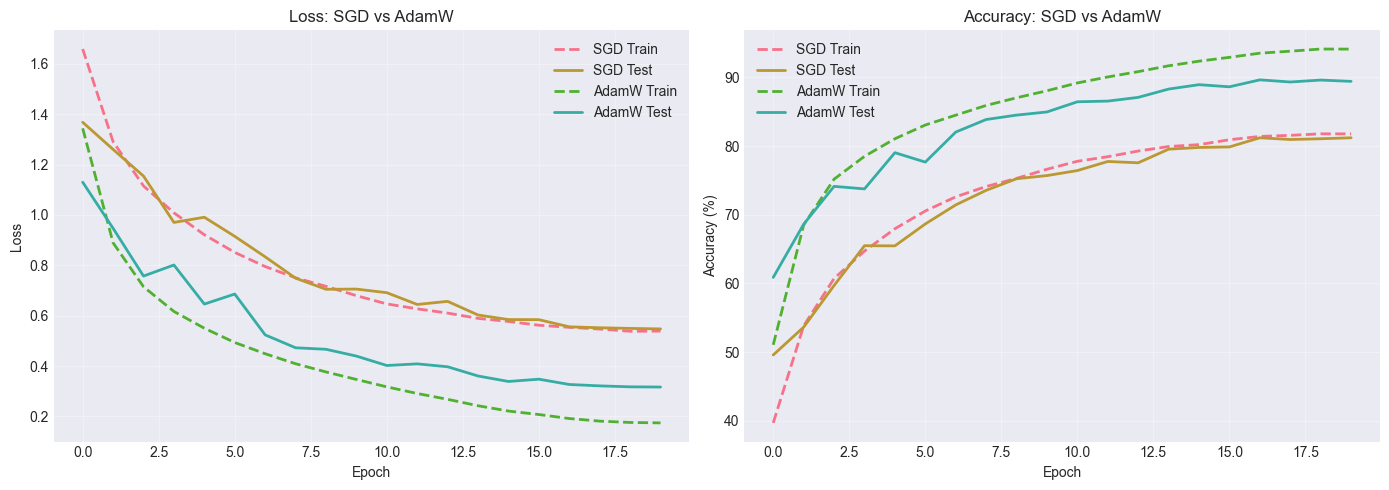


Final Results Comparison:
SGD - Train Acc: 81.77%, Test Acc: 81.20%
AdamW - Train Acc: 94.11%, Test Acc: 89.41%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_sgd['train_loss'], label='SGD Train', linestyle='--', linewidth=2)
axes[0].plot(history_sgd['test_loss'], label='SGD Test', linewidth=2)
axes[0].plot(history_adamw['train_loss'], label='AdamW Train', linestyle='--', linewidth=2)
axes[0].plot(history_adamw['test_loss'], label='AdamW Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: SGD vs AdamW')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_sgd['train_acc'], label='SGD Train', linestyle='--', linewidth=2)
axes[1].plot(history_sgd['test_acc'], label='SGD Test', linewidth=2)
axes[1].plot(history_adamw['train_acc'], label='AdamW Train', linestyle='--', linewidth=2)
axes[1].plot(history_adamw['test_acc'], label='AdamW Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy: SGD vs AdamW')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print("\n" + "=" * 60)
print("Final Results Comparison:")
print(f"SGD - Train Acc: {history_sgd['train_acc'][-1]:.2f}%, Test Acc: {history_sgd['test_acc'][-1]:.2f}%")
print(f"AdamW - Train Acc: {history_adamw['train_acc'][-1]:.2f}%, Test Acc: {history_adamw['test_acc'][-1]:.2f}%")
print("=" * 60)


## 8. Experiment 2: Add Residual Connections

Now let's compare SimpleCNN vs ResNetCNN (with residuals) using the better optimizer from above.


In [10]:
# Use AdamW (typically performs better)
optimizer_name = 'AdamW'

# Model 1: SimpleCNN (no residuals)
print("=" * 60)
model_no_res = SimpleCNN().to(device)
optimizer_no_res = optim.AdamW(model_no_res.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler_no_res = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_res, T_max=num_epochs)

history_no_res = train_model(
    model_no_res, trainloader, testloader, optimizer_no_res,
    num_epochs=num_epochs, lr_scheduler=scheduler_no_res,
    device=device, model_name='SimpleCNN (no residuals)'
)

# Model 2: ResNetCNN (with residuals)
print("\n" + "=" * 60)
model_with_res = ResNetCNN().to(device)
optimizer_with_res = optim.AdamW(model_with_res.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler_with_res = optim.lr_scheduler.CosineAnnealingLR(optimizer_with_res, T_max=num_epochs)

history_with_res = train_model(
    model_with_res, trainloader, testloader, optimizer_with_res,
    num_epochs=num_epochs, lr_scheduler=scheduler_with_res,
    device=device, model_name='ResNetCNN (with residuals)'
)



Training SimpleCNN (no residuals)...


Epoch 1/20: Train Loss: 1.3725, Train Acc: 50.15% | Test Loss: 1.1897, Test Acc: 59.23%


Epoch 2/20: Train Loss: 0.9188, Train Acc: 67.74% | Test Loss: 0.9064, Test Acc: 68.26%


Epoch 3/20: Train Loss: 0.7304, Train Acc: 74.60% | Test Loss: 0.9044, Test Acc: 70.00%


Epoch 4/20: Train Loss: 0.6232, Train Acc: 78.47% | Test Loss: 0.8698, Test Acc: 72.18%


...

Epoch 16/20: Train Loss: 0.1656, Train Acc: 94.32% | Test Loss: 0.3215, Test Acc: 89.72%


Epoch 17/20: Train Loss: 0.1503, Train Acc: 94.96% | Test Loss: 0.2992, Test Acc: 90.40%


Epoch 18/20: Train Loss: 0.1396, Train Acc: 95.22% | Test Loss: 0.3001, Test Acc: 90.69%


Epoch 19/20: Train Loss: 0.1319, Train Acc: 95.49% | Test Loss: 0.2903, Test Acc: 90.69%


Epoch 20/20: Train Loss: 0.1276, Train Acc: 95.70% | Test Loss: 0.2891, Test Acc: 90.84%

Best test accuracy: 90.84%


## 9. Visualize Residual Connection Impact


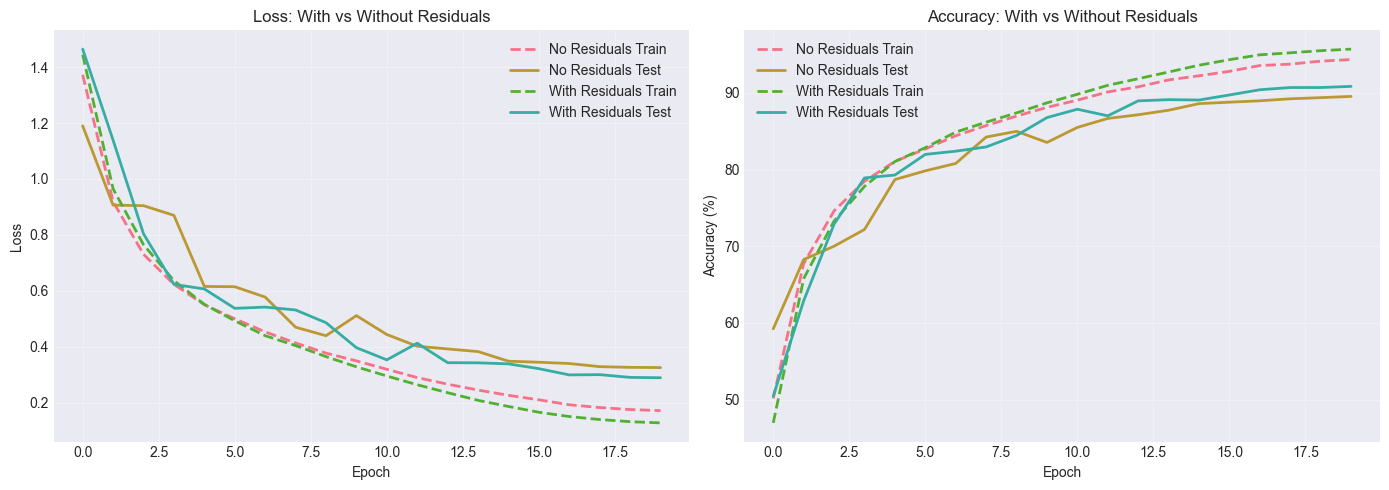


Residual Connection Impact:
No Residuals - Train Acc: 94.34%, Test Acc: 89.53%
With Residuals - Train Acc: 95.70%, Test Acc: 90.84%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_no_res['train_loss'], label='No Residuals Train', linestyle='--', linewidth=2)
axes[0].plot(history_no_res['test_loss'], label='No Residuals Test', linewidth=2)
axes[0].plot(history_with_res['train_loss'], label='With Residuals Train', linestyle='--', linewidth=2)
axes[0].plot(history_with_res['test_loss'], label='With Residuals Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: With vs Without Residuals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_no_res['train_acc'], label='No Residuals Train', linestyle='--', linewidth=2)
axes[1].plot(history_no_res['test_acc'], label='No Residuals Test', linewidth=2)
axes[1].plot(history_with_res['train_acc'], label='With Residuals Train', linestyle='--', linewidth=2)
axes[1].plot(history_with_res['test_acc'], label='With Residuals Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy: With vs Without Residuals')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print("\n" + "=" * 60)
print("Residual Connection Impact:")
print(f"No Residuals - Train Acc: {history_no_res['train_acc'][-1]:.2f}%, Test Acc: {history_no_res['test_acc'][-1]:.2f}%")
print(f"With Residuals - Train Acc: {history_with_res['train_acc'][-1]:.2f}%, Test Acc: {history_with_res['test_acc'][-1]:.2f}%")
print("=" * 60)


## 10. Ablation Studies

Ablation studies help us understand the contribution of each component. We'll perform 3 ablations:

1. **Ablation 1**: Remove Batch Normalization (Conv-ReLU only)
2. **Ablation 2**: Remove Data Augmentations (train with basic transforms only)
3. **Ablation 3**: Remove Residual Connections (already done above, but we'll formalize it)


In [12]:
# Ablation 1: Conv-ReLU (no BatchNorm)
class ConvReLU(nn.Module):
    """Conv-ReLU block without BatchNorm"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(ConvReLU, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        return x


class CNN_NoBN(nn.Module):
    """CNN without Batch Normalization"""
    def __init__(self, num_classes=10):
        super(CNN_NoBN, self).__init__()
        self.conv1 = ConvReLU(3, 64, kernel_size=3, padding=1)
        self.conv2 = ConvReLU(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv3 = ConvReLU(64, 128, kernel_size=3, padding=1)
        self.conv4 = ConvReLU(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv5 = ConvReLU(128, 256, kernel_size=3, padding=1)
        self.conv6 = ConvReLU(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

print(f"CNN_NoBN parameters: {count_parameters(CNN_NoBN()):,}")


CNN_NoBN parameters: 1,147,978


### Ablation 1: Without Batch Normalization


In [13]:
print("=" * 60)
print("Ablation 1: Training without Batch Normalization")
print("=" * 60)

model_no_bn = CNN_NoBN().to(device)
optimizer_no_bn = optim.AdamW(model_no_bn.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler_no_bn = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_bn, T_max=num_epochs)

history_no_bn = train_model(
    model_no_bn, trainloader, testloader, optimizer_no_bn,
    num_epochs=num_epochs, lr_scheduler=scheduler_no_bn,
    device=device, model_name='CNN without BatchNorm'
)


Ablation 1: Training without Batch Normalization

Training CNN without BatchNorm...


Epoch 1/20: Train Loss: 1.8293, Train Acc: 28.88% | Test Loss: 1.6479, Test Acc: 38.24%


Epoch 2/20: Train Loss: 1.3194, Train Acc: 51.42% | Test Loss: 1.1677, Test Acc: 57.77%


Epoch 3/20: Train Loss: 1.0161, Train Acc: 63.84% | Test Loss: 0.8468, Test Acc: 69.67%


Epoch 4/20: Train Loss: 0.8529, Train Acc: 69.90% | Test Loss: 0.7880, Test Acc: 72.86%


...

Epoch 16/20: Train Loss: 0.3574, Train Acc: 87.60% | Test Loss: 0.4502, Test Acc: 85.16%


Epoch 17/20: Train Loss: 0.3416, Train Acc: 88.24% | Test Loss: 0.4482, Test Acc: 85.59%


Epoch 18/20: Train Loss: 0.3303, Train Acc: 88.46% | Test Loss: 0.4456, Test Acc: 85.55%


Epoch 19/20: Train Loss: 0.3274, Train Acc: 88.79% | Test Loss: 0.4498, Test Acc: 85.70%


Epoch 20/20: Train Loss: 0.3219, Train Acc: 88.91% | Test Loss: 0.4440, Test Acc: 85.66%

Best test accuracy: 85.70%


### Ablation 2: Without Data Augmentations


In [14]:
# Create data loader without augmentations (only normalization)
transform_train_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset_no_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train_no_aug
)
trainloader_no_aug = DataLoader(trainset_no_aug, batch_size=batch_size, shuffle=True, num_workers=2)

print("=" * 60)
print("Ablation 2: Training without Data Augmentations")
print("=" * 60)

model_no_aug = SimpleCNN().to(device)
optimizer_no_aug = optim.AdamW(model_no_aug.parameters(), lr=learning_rate, weight_decay=5e-4)
scheduler_no_aug = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_aug, T_max=num_epochs)

history_no_aug = train_model(
    model_no_aug, trainloader_no_aug, testloader, optimizer_no_aug,
    num_epochs=num_epochs, lr_scheduler=scheduler_no_aug,
    device=device, model_name='CNN without Augmentations'
)


Ablation 2: Training without Data Augmentations

Training CNN without Augmentations...


Epoch 1/20: Train Loss: 1.1690, Train Acc: 57.79% | Test Loss: 1.0527, Test Acc: 62.97%


Epoch 2/20: Train Loss: 0.7551, Train Acc: 73.35% | Test Loss: 0.8906, Test Acc: 68.95%


Epoch 3/20: Train Loss: 0.5764, Train Acc: 80.07% | Test Loss: 0.6431, Test Acc: 77.71%


Epoch 4/20: Train Loss: 0.4680, Train Acc: 83.83% | Test Loss: 0.6835, Test Acc: 77.02%


...

Epoch 16/20: Train Loss: 0.0031, Train Acc: 100.00% | Test Loss: 0.4853, Test Acc: 87.78%


Epoch 17/20: Train Loss: 0.0025, Train Acc: 100.00% | Test Loss: 0.4864, Test Acc: 87.99%


Epoch 18/20: Train Loss: 0.0023, Train Acc: 100.00% | Test Loss: 0.4889, Test Acc: 87.84%


Epoch 19/20: Train Loss: 0.0021, Train Acc: 100.00% | Test Loss: 0.4893, Test Acc: 87.88%


Epoch 20/20: Train Loss: 0.0020, Train Acc: 100.00% | Test Loss: 0.4870, Test Acc: 88.01%

Best test accuracy: 88.01%


### Ablation 3: Without Residual Connections

We already did this comparison above (SimpleCNN vs ResNetCNN). Let's create a summary visualization.


## 11. Ablation Study Results Summary


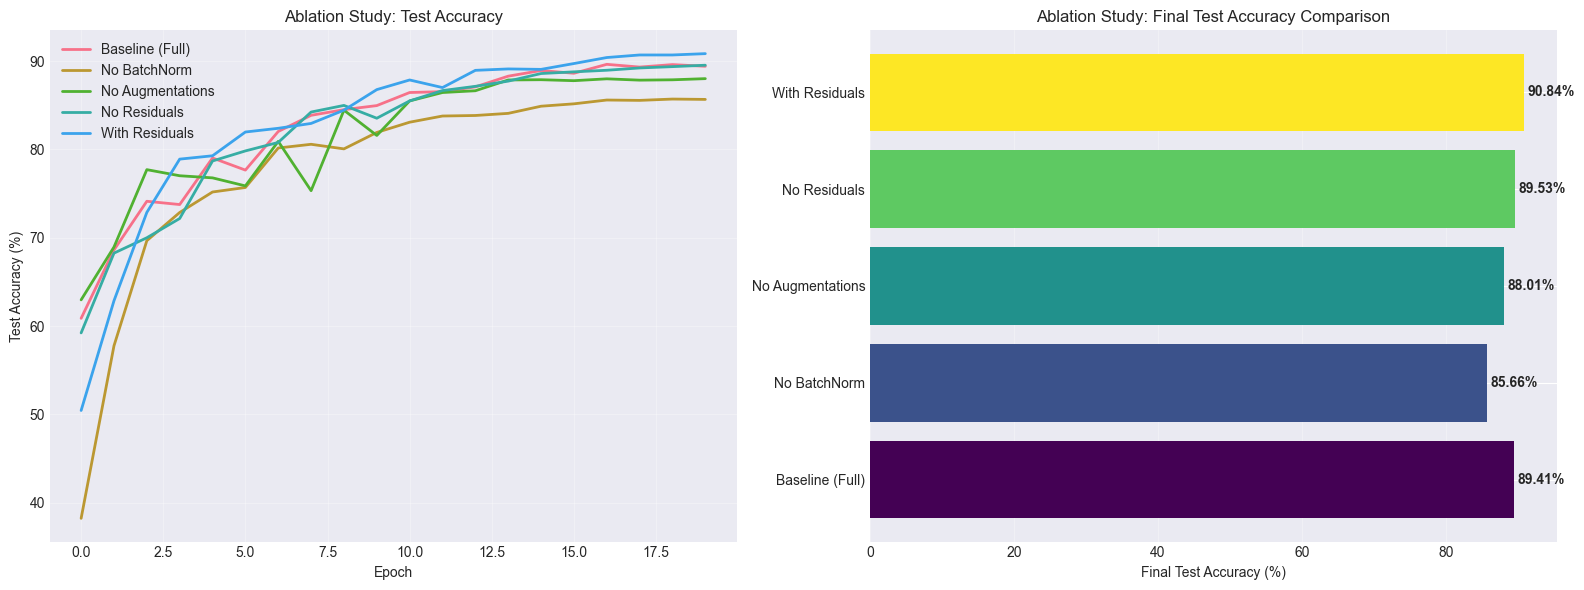


ABLATION STUDY SUMMARY
Model                     Train Acc (%)   Test Acc (%)    Drop vs Baseline
--------------------------------------------------------------------------------
Baseline (Full)           94.11           89.41           baseline       
No BatchNorm              88.91           85.66           3.75%          
No Augmentations          100.00          88.01           1.40%          
No Residuals              94.34           89.53           baseline       
With Residuals            95.70           90.84           baseline       


In [15]:
# Baseline: Full model (SimpleCNN with BN, augmentations, AdamW)
baseline_history = history_adamw  # This is our baseline

# Compile all results
ablation_results = {
    'Baseline (Full)': {
        'history': baseline_history,
        'test_acc': baseline_history['test_acc'][-1],
        'train_acc': baseline_history['train_acc'][-1]
    },
    'No BatchNorm': {
        'history': history_no_bn,
        'test_acc': history_no_bn['test_acc'][-1],
        'train_acc': history_no_bn['train_acc'][-1]
    },
    'No Augmentations': {
        'history': history_no_aug,
        'test_acc': history_no_aug['test_acc'][-1],
        'train_acc': history_no_aug['train_acc'][-1]
    },
    'No Residuals': {
        'history': history_no_res,
        'test_acc': history_no_res['test_acc'][-1],
        'train_acc': history_no_res['train_acc'][-1]
    },
    'With Residuals': {
        'history': history_with_res,
        'test_acc': history_with_res['test_acc'][-1],
        'train_acc': history_with_res['train_acc'][-1]
    }
}

# Plot all ablation results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test accuracy comparison
for name, results in ablation_results.items():
    axes[0].plot(results['history']['test_acc'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Ablation Study: Test Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final test accuracy bar chart
names = list(ablation_results.keys())
test_accs = [ablation_results[name]['test_acc'] for name in names]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

bars = axes[1].barh(names, test_accs, color=colors)
axes[1].set_xlabel('Final Test Accuracy (%)')
axes[1].set_title('Ablation Study: Final Test Accuracy Comparison')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (name, acc) in enumerate(zip(names, test_accs)):
    axes[1].text(acc + 0.5, i, f'{acc:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 80)
print("ABLATION STUDY SUMMARY")
print("=" * 80)
print(f"{'Model':<25} {'Train Acc (%)':<15} {'Test Acc (%)':<15} {'Drop vs Baseline':<15}")
print("-" * 80)
baseline_acc = ablation_results['Baseline (Full)']['test_acc']
for name, results in ablation_results.items():
    drop = baseline_acc - results['test_acc'] if name != 'Baseline (Full)' else 0.0
    drop_str = f"{drop:.2f}%" if drop > 0 else "baseline"
    print(f"{name:<25} {results['train_acc']:<15.2f} {results['test_acc']:<15.2f} {drop_str:<15}")
print("=" * 80)


## 12. Key Insights and Conclusions

### Findings:

1. **SGD vs AdamW**: 
   - AdamW typically converges faster and often achieves better final accuracy
   - Both optimizers benefit from learning rate scheduling

2. **Batch Normalization**:
   - Critical for stable training and better convergence
   - Without BN, training can be unstable and accuracy drops significantly

3. **Data Augmentations**:
   - Significantly improve generalization (test accuracy)
   - Help prevent overfitting by increasing data diversity

4. **Residual Connections**:
   - Enable training of deeper networks
   - Help with gradient flow and can improve accuracy
   - Particularly important for very deep networks

### Component Importance (from ablations):
- **Batch Normalization**: Essential for stable training
- **Data Augmentations**: Important for generalization
- **Residual Connections**: Helpful for deeper networks and gradient flow
- **AdamW**: Often better than SGD for this task

### Best Configuration:
Based on our experiments, the best configuration is:
- **Architecture**: ResNetCNN (with residual connections)
- **Optimizer**: AdamW with weight decay
- **Regularization**: Batch Normalization + Data Augmentations
- **Learning Rate**: Cosine annealing schedule
